In [2]:
import pickle
with open("pre_split_data.pkl", "rb") as f:
    X, y, categorical, numerical = pickle.load(f)

For segmentation model, we use K-means clustering. 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# One hot encode categorical features
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_ohe = pd.DataFrame(ohe.fit_transform(X[categorical]),
                           columns=ohe.get_feature_names_out(categorical),
                           index=X.index)

X_enc = pd.concat([X[numerical], X_ohe], axis=1)


In [4]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_enc)
remaining_columns = X_enc.columns[selector.get_support()]
print(remaining_columns)

Index(['age', 'detailed industry recode', 'detailed occupation recode',
       'wage per hour', 'sex', 'member of a labor union', 'capital gains',
       'capital losses', 'dividends from stocks', 'weight',
       ...
       'country of birth father_Mexico', 'country of birth father_Puerto-Rico',
       'country of birth father_United-States',
       'country of birth mother_Mexico', 'country of birth mother_Puerto-Rico',
       'country of birth mother_United-States', 'country of birth self_Mexico',
       'country of birth self_United-States',
       'citizenship_Foreign born- U S citizen by naturalization',
       'citizenship_Native- Born in the United States'],
      dtype='object', length=131)


In [5]:

# Scale all columns using standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

We first run a K-Means directly on scaled data.

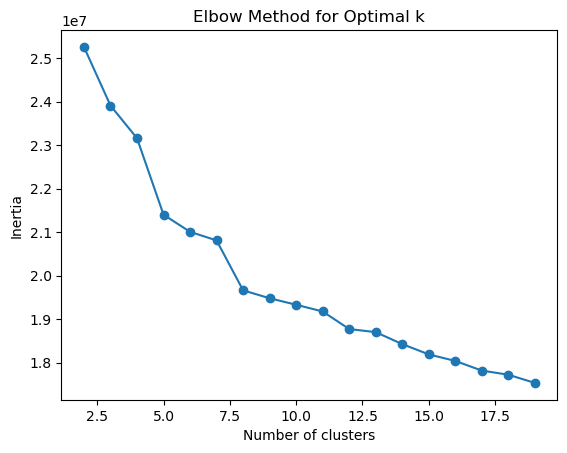

In [6]:
inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

Next we attempt a PCA dimension reduction since our data is very sparse.
We find an acceptable number of components by looking at the exxplained variance. 

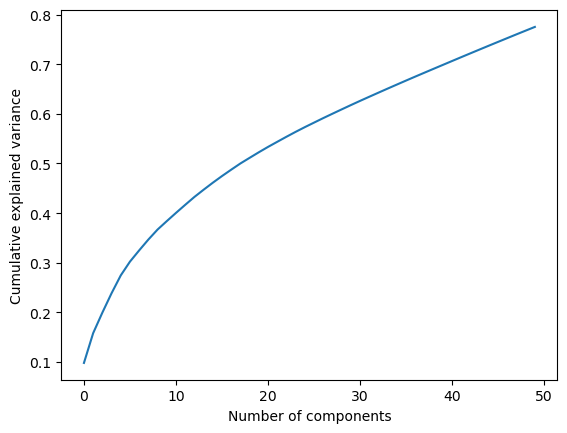

In [7]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_scaled)

explained_ratio = svd.explained_variance_ratio_
cumulative_variance = explained_ratio.cumsum()

import matplotlib.pyplot as plt
plt.plot(cumulative_variance)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

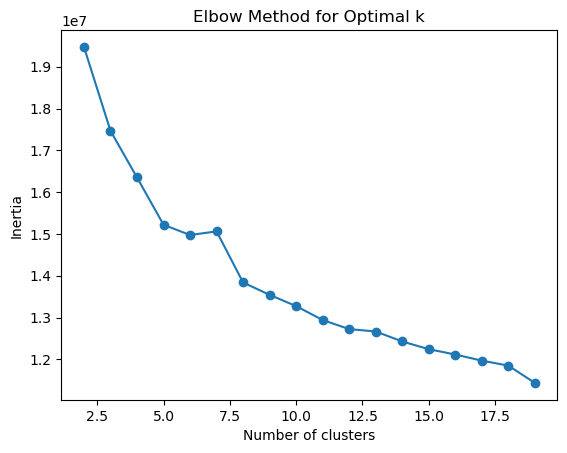

In [8]:
inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_svd)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

K-Means on Truncated SVD reduced data and on scaled only data both show an "elbow" at number of clsuters = 8. 
We now train a K-Means with k = 8 to get cluster assignment.

In [9]:
k = 8
kmeans = KMeans(n_clusters=k, 
                n_init=10,
                random_state=27)
clusters = kmeans.fit_predict(X_svd)  
X['cluster'] = clusters

In [10]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_idx = np.random.choice(len(X_svd), size=10000, replace=False)
score = silhouette_score(X_svd[sample_idx], clusters[sample_idx])
print(f"Silhouette score (sample): {score:.3f}")

Silhouette score (sample): 0.125


Given the cluster labels, we group data by their cluster.
We can calculate the mean values on the numerical columns

In [ ]:
# need a different split of num vs cat

numerical_summary  = X.groupby('cluster')[numerical].mean()
print(numerical_summary)

               age  detailed industry recode  detailed occupation recode  \
cluster                                                                    
0        31.508880                 13.284942                   10.815058   
1         7.978620                  0.045480                    0.048935   
2        24.501827                 27.483126                   23.221004   
3        41.796679                 31.356296                   21.219644   
4        59.831751                  0.003055                    0.004201   
5        27.935182                 17.698488                   13.435826   
6        41.117607                 17.412706                   15.949365   
7        42.868280                 30.702234                   21.368313   

         wage per hour       sex  member of a labor union  capital gains  \
cluster                                                                    
0            36.915058  0.442085                -0.018919     232.447876   
1          

In [14]:
X['cluster'].value_counts()

cluster
1    44855
4    36660
3    35594
7    30618
2    16416
6    14812
5    14749
0     2590
Name: count, dtype: int64